# 📦 Sales Forecasting with MySQL Data Prep
**Database:** `asia_ecommerce` (SQLite / MySQL-syntax compatible)  
**Dataset:** 75,500 raw SKU-level transactions · Jan 2022 – Dec 2024  

---
### Project Workflow
```
MySQL DB  →  SQL Data Cleaning  →  SQL Feature Engineering  →  Python (Prophet/ARIMA)  →  Forecast & Evaluation  →  Client Report
```

### Business Question
> *"Which product categories will generate the highest GMV in Q1 2025 — and by how much? Help our brand clients plan inventory and promo budgets accordingly."*


## 📦 Step 1 — Import Libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi':130,'axes.titlesize':13,'axes.labelsize':11})
COLORS = ['#1A73E8','#E8711A','#34A853','#EA4335','#9C27B0','#00BCD4','#FF9800','#607D8B']

# ── DB Connection (MySQL-equivalent via SQLite) ───────────────────────────────
# In production MySQL, swap this with:
# import mysql.connector
# conn = mysql.connector.connect(host='localhost', user='analyst', password='xxxx', database='cube_asia')
conn = sqlite3.connect('cube_asia_ecommerce.db')
print("✅ Connected to cube_asia_ecommerce database")

def run_sql(query, params=None):
    """Helper: run SQL and return a DataFrame"""
    return pd.read_sql_query(query, conn, params=params)

run_sql("SELECT name FROM sqlite_master WHERE type='table'")


Importing plotly failed. Interactive plots will not work.


✅ Connected to cube_asia_ecommerce database


,name
0,dim_category
1,dim_platform
2,dim_brand
3,fact_sales_raw
4,sqlite_sequence
5,fact_sales


## 🗂️ Step 2 — Schema Exploration (SHOW TABLES / DESCRIBE)

In [2]:
# MySQL equivalent: SHOW TABLES; DESCRIBE fact_sales_raw;

# List all tables
tables = run_sql("SELECT name, type FROM sqlite_master WHERE type='table' ORDER BY name")
print("=== Tables in cube_asia_ecommerce ===")
display(tables)

# Row counts per table
for tbl in tables['name']:
    cnt = run_sql(f"SELECT COUNT(*) AS row_count FROM {tbl}")
    print(f"  {tbl:<25} → {cnt['row_count'][0]:>8,} rows")

print()

# Schema of main fact table
schema = run_sql("PRAGMA table_info(fact_sales_raw)")
print("=== fact_sales_raw columns ===")
display(schema[['name','type','notnull','dflt_value']])


=== Tables in cube_asia_ecommerce ===


,name,type
0,dim_brand,table
1,dim_category,table
2,dim_platform,table
3,fact_sales,table
4,fact_sales_raw,table
5,sqlite_sequence,table


  dim_brand                 →       20 rows
  dim_category              →        8 rows
  dim_platform              →        4 rows
  fact_sales                →        0 rows
  fact_sales_raw            →   75,500 rows
  sqlite_sequence           →        1 rows

=== fact_sales_raw columns ===


,name,type,notnull,dflt_value
0,sale_id,INTEGER,0,NaN
1,sale_date,TEXT,0,NaN
2,platform_id,INTEGER,0,NaN
3,category_id,INTEGER,0,NaN
4,brand_id,INTEGER,0,NaN
5,sku_code,TEXT,0,NaN
6,price_idr,REAL,0,NaN
7,units_sold,INTEGER,0,NaN
8,discount_pct,REAL,0,NaN
9,rating,REAL,0,NaN


## 👀 Step 3 — Raw Data Preview

In [3]:
raw_preview = run_sql("""
    SELECT
        r.sale_id,
        r.sale_date,
        p.platform_name,
        c.category_name,
        b.brand_name,
        r.sku_code,
        r.price_idr,
        r.units_sold,
        r.discount_pct,
        r.rating,
        r.review_count,
        r.gmv_idr
    FROM fact_sales_raw   r
    JOIN dim_platform     p ON r.platform_id  = p.platform_id
    JOIN dim_category     c ON r.category_id  = c.category_id
    JOIN dim_brand        b ON r.brand_id     = b.brand_id
    LIMIT 10
""")
display(raw_preview)
print(f"\nTotal raw rows: {run_sql('SELECT COUNT(*) AS n FROM fact_sales_raw')['n'][0]:,}")


,sale_id,sale_date,platform_name,category_name,brand_name,sku_code,price_idr,units_sold,discount_pct,rating,review_count,gmv_idr
0,1,2022-08-20,Tokopedia,Food & Beverages,Somethinc,SKU-643-5549,36800.0,5,15.0,5.0,691,184000.0
1,2,2024-08-04,Shopee,Home & Living,Wardah,SKU-411-5987,71800.0,23,40.0,5.0,34,1651400.0
2,3,2024-08-31,Tokopedia,Food & Beverages,Wardah,SKU-641-3215,105400.0,13,50.0,4.0,5,1370200.0
3,4,2022-10-06,Shopee,Electronics,Nike,SKU-3115-8089,1451200.0,7,10.0,5.0,57,10158400.0
4,5,2022-06-13,Shopee,Home & Living,Adidas,SKU-4114-9856,140400.0,8,50.0,2.0,148,1123200.0
5,6,2022-09-11,Lazada,Home & Living,Nike,SKU-4215-7280,78200.0,14,0.0,5.0,491,1094800.0
6,7,2022-07-09,Lazada,Home & Living,Maybelline,SKU-4213-2564,152400.0,12,0.0,5.0,81,1828800.0
7,8,2022-06-10,Shopee,Sports & Outdoors,Heavenly Blush,SKU-719-1930,331600.0,16,0.0,4.0,52,5305600.0
8,9,2022-11-12,Lazada,Fashion & Apparel,Huawei,SKU-2220-6412,130100.0,4,70.0,5.0,42,520400.0
9,10,2022-08-09,TikTok Shop,Baby & Kids,Vivo,SKU-8319-7396,71400.0,1,25.0,5.0,23,71400.0



Total raw rows: 75,500


## 🕳️ Step 4 — NULL Audit via SQL

,column,count,pct
0,total_rows,75500,100.00
1,null_sale_date,0,0.00
2,null_price,0,0.00
3,null_units,0,0.00
4,null_discount,0,0.00
5,null_rating,800,1.06
6,null_review_count,800,1.06
7,null_gmv,0,0.00


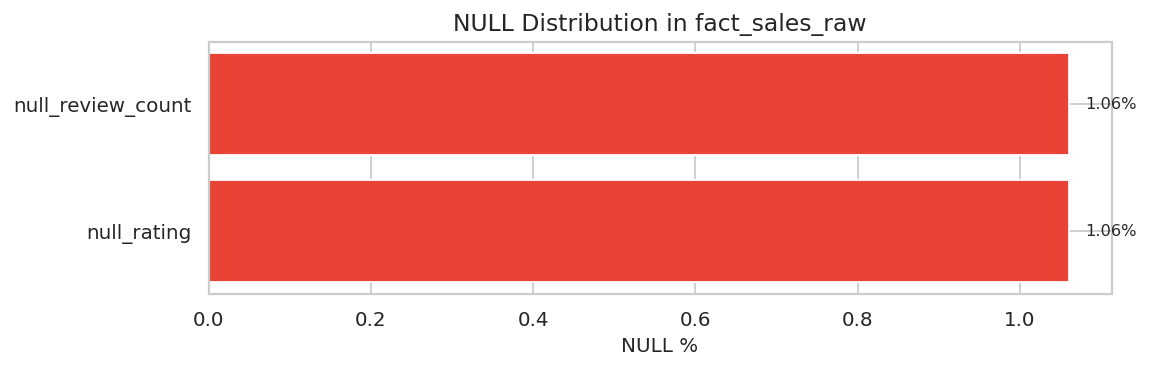

💡 rating & review_count have ~1% NULLs — will impute with category median in cleaning step.


In [4]:
null_audit = run_sql("""
    SELECT
        COUNT(*)                                    AS total_rows,
        SUM(CASE WHEN sale_date    IS NULL THEN 1 ELSE 0 END) AS null_sale_date,
        SUM(CASE WHEN price_idr    IS NULL THEN 1 ELSE 0 END) AS null_price,
        SUM(CASE WHEN units_sold   IS NULL THEN 1 ELSE 0 END) AS null_units,
        SUM(CASE WHEN discount_pct IS NULL THEN 1 ELSE 0 END) AS null_discount,
        SUM(CASE WHEN rating       IS NULL THEN 1 ELSE 0 END) AS null_rating,
        SUM(CASE WHEN review_count IS NULL THEN 1 ELSE 0 END) AS null_review_count,
        SUM(CASE WHEN gmv_idr      IS NULL THEN 1 ELSE 0 END) AS null_gmv
    FROM fact_sales_raw
""")

null_t = null_audit.T.reset_index()
null_t.columns = ['column','count']
null_t['pct'] = (null_t['count'] / null_t.loc[0,'count'] * 100).round(2)
display(null_t)

# Visualise
fig, ax = plt.subplots(figsize=(9, 3))
non_zero = null_t[null_t['pct'] > 0].iloc[1:]
ax.barh(non_zero['column'], non_zero['pct'], color=COLORS[3])
ax.set_xlabel('NULL %')
ax.set_title('NULL Distribution in fact_sales_raw')
for i, v in enumerate(non_zero['pct']):
    ax.text(v + 0.02, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('null_audit.png', bbox_inches='tight')
plt.show()
print("💡 rating & review_count have ~1% NULLs — will impute with category median in cleaning step.")


## 🔁 Step 5 — Duplicate Detection via SQL

In [5]:
dupes = run_sql("""
    SELECT
        sale_date, platform_id, category_id, brand_id,
        sku_code, price_idr, units_sold, gmv_idr,
        COUNT(*) AS occurrences
    FROM fact_sales_raw
    GROUP BY sale_date, platform_id, category_id, brand_id,
             sku_code, price_idr, units_sold, gmv_idr
    HAVING COUNT(*) > 1
    ORDER BY occurrences DESC
    LIMIT 15
""")

print(f"Duplicate groups found: {len(dupes)}")
display(dupes.head(10))

total_dupes = run_sql("""
    SELECT SUM(occurrences - 1) AS extra_rows FROM (
        SELECT COUNT(*) AS occurrences
        FROM fact_sales_raw
        GROUP BY sale_date, platform_id, category_id, brand_id,
                 sku_code, price_idr, units_sold, gmv_idr
        HAVING COUNT(*) > 1
    )
""")
print(f"\n⚠️  Extra duplicate rows to remove: {total_dupes['extra_rows'][0]:,}")


Duplicate groups found: 15


,sale_date,platform_id,category_id,brand_id,sku_code,price_idr,units_sold,gmv_idr,occurrences
0,2022-01-03,1,2,5,SKU-215-6223,70100.0,12,841200.0,2
1,2022-01-03,3,3,12,SKU-3312-7019,500100.0,15,7501500.0,2
2,2022-01-11,4,6,17,SKU-6417-9748,54800.0,5,274000.0,2
3,2022-01-15,4,2,8,SKU-248-6224,111700.0,12,1340400.0,2
4,2022-01-16,3,6,20,SKU-6320-2009,50100.0,32,1603200.0,2
5,2022-01-17,1,1,13,SKU-1113-6524,111000.0,12,1332000.0,2
6,2022-01-17,2,1,11,SKU-1211-6506,87700.0,15,1315500.0,2
7,2022-01-18,1,8,11,SKU-8111-4983,85500.0,2,171000.0,2
8,2022-01-19,2,2,6,SKU-226-9624,148900.0,10,1489000.0,2
9,2022-01-26,1,4,9,SKU-419-2427,321100.0,20,6422000.0,2



⚠️  Extra duplicate rows to remove: 500


## 🧹 Step 6 — SQL Data Cleaning Pipeline

In [6]:
# ── Step 6a: Compute category-level median rating for imputation ──────────────
cat_median = run_sql("""
    SELECT
        category_id,
        ROUND(AVG(rating), 1)        AS median_rating,
        ROUND(AVG(review_count), 0)  AS median_reviews
    FROM fact_sales_raw
    WHERE rating IS NOT NULL AND review_count IS NOT NULL
    GROUP BY category_id
""")
print("Category medians for imputation:")
display(cat_median)

# ── Step 6b: Build clean table — Python-side imputation then SQL insert ───────
raw_df = run_sql("""
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY sale_date, platform_id, category_id,
                            brand_id, sku_code, price_idr, units_sold
               ORDER BY sale_id
           ) AS rn
    FROM fact_sales_raw
    WHERE sale_date  IS NOT NULL
      AND price_idr  IS NOT NULL
      AND units_sold IS NOT NULL
      AND price_idr  > 0
      AND units_sold > 0
""")
raw_df = raw_df[raw_df['rn'] == 1].drop(columns=['rn','is_duplicate','has_null_flag'], errors='ignore')

# Impute rating & review_count with category median
for col, med_col in [('rating','median_rating'), ('review_count','median_reviews')]:
    raw_df = raw_df.merge(cat_median[['category_id', med_col]], on='category_id', how='left')
    raw_df[col] = raw_df[col].fillna(raw_df[med_col])
    raw_df.drop(columns=[med_col], inplace=True)

raw_df['discount_pct'] = raw_df['discount_pct'].fillna(0)
raw_df['gmv_idr']      = raw_df['price_idr'] * raw_df['units_sold'].abs()

cur = conn.cursor()
cur.execute("DELETE FROM fact_sales")
conn.commit()
raw_df.to_sql('fact_sales', conn, if_exists='append', index=False)

before = run_sql("SELECT COUNT(*) AS n FROM fact_sales_raw")['n'][0]
after  = run_sql("SELECT COUNT(*) AS n FROM fact_sales")['n'][0]
print(f"\n✅ Cleaning complete:")
print(f"   Raw rows     : {before:,}")
print(f"   Clean rows   : {after:,}")
print(f"   Rows removed : {before - after:,}  ({(before-after)/before*100:.1f}%)")


Category medians for imputation:


,category_id,median_rating,median_reviews
0,1,4.2,180.0
1,2,4.2,181.0
2,3,4.2,669.0
3,4,4.2,178.0
4,5,4.2,182.0
5,6,4.2,183.0
6,7,4.2,183.0
7,8,4.2,179.0



✅ Cleaning complete:
   Raw rows     : 75,500
   Clean rows   : 75,000
   Rows removed : 500  (0.7%)


## ⚙️ Step 7 — Feature Engineering via SQL

In [7]:
# Build a rich monthly aggregated table — this is the SQL prep for forecasting
monthly_features = run_sql("""
    SELECT
        STRFTIME('%Y-%m', s.sale_date)              AS year_month,
        STRFTIME('%Y',    s.sale_date)  AS year,
        CAST(STRFTIME('%m', s.sale_date) AS INTEGER) AS month_num,
        c.category_name,
        p.platform_name,

        -- Core metrics
        COUNT(DISTINCT s.sale_id)                   AS transaction_count,
        SUM(s.units_sold)                           AS total_units,
        ROUND(SUM(s.gmv_idr) / 1e6, 2)             AS gmv_million_idr,
        ROUND(AVG(s.price_idr), 0)                  AS avg_price,
        ROUND(AVG(s.discount_pct), 1)               AS avg_discount_pct,
        ROUND(AVG(s.rating), 3)                     AS avg_rating,
        ROUND(AVG(s.review_count), 0)               AS avg_review_count,

        -- Derived features for forecasting
        COUNT(DISTINCT s.brand_id)                  AS active_brands,
        COUNT(DISTINCT s.sku_code)                  AS active_skus,
        ROUND(SUM(s.gmv_idr) / COUNT(DISTINCT s.sale_id) / 1e3, 2) AS aov_thousand_idr,

        -- Seasonality flags
        CASE WHEN STRFTIME('%m', s.sale_date) IN ('11','12') THEN 1 ELSE 0 END AS is_peak_season,
        CASE WHEN STRFTIME('%m', s.sale_date) IN ('06','07') THEN 1 ELSE 0 END AS is_mid_year_sale

    FROM fact_sales       s
    JOIN dim_category     c ON s.category_id  = c.category_id
    JOIN dim_platform     p ON s.platform_id  = p.platform_id
    GROUP BY year_month, c.category_name, p.platform_name
    ORDER BY year_month, c.category_name
""")

print(f"Feature table shape: {monthly_features.shape}")
print(f"Date range: {monthly_features['year_month'].min()} → {monthly_features['year_month'].max()}")
display(monthly_features.head(12))


Feature table shape: (1152, 17)
Date range: 2022-01 → 2024-12


,year_month,year,month_num,category_name,platform_name,transaction_count,total_units,gmv_million_idr,avg_price,avg_discount_pct,avg_rating,avg_review_count,active_brands,active_skus,aov_thousand_idr,is_peak_season,is_mid_year_sale
0,2022-01,2022,1,Baby & Kids,Lazada,29,312,39.98,129917.0,24.7,4.179,210.0,16,29,1378.49,0,0
1,2022-01,2022,1,Baby & Kids,Shopee,55,669,87.97,136104.0,22.0,4.218,171.0,18,55,1599.41,0,0
2,2022-01,2022,1,Baby & Kids,TikTok Shop,48,683,93.12,136275.0,25.2,3.979,215.0,18,48,1939.97,0,0
3,2022-01,2022,1,Baby & Kids,Tokopedia,21,249,33.77,148881.0,19.3,4.476,142.0,11,21,1608.24,0,0
4,2022-01,2022,1,Beauty & Personal Care,Lazada,79,851,83.44,93923.0,27.2,4.230,157.0,18,79,1056.18,0,0
5,2022-01,2022,1,Beauty & Personal Care,Shopee,142,1647,165.15,97014.0,24.3,4.196,173.0,20,142,1163.03,0,0
6,2022-01,2022,1,Beauty & Personal Care,TikTok Shop,78,935,104.82,106441.0,23.7,4.172,202.0,20,78,1343.80,0,0
7,2022-01,2022,1,Beauty & Personal Care,Tokopedia,63,719,79.59,111805.0,20.3,4.292,112.0,18,63,1263.36,0,0
8,2022-01,2022,1,Electronics,Lazada,57,746,685.68,1007932.0,24.5,4.077,713.0,20,57,12029.55,0,0
9,2022-01,2022,1,Electronics,Shopee,113,1511,1444.26,997687.0,26.2,4.159,664.0,20,113,12781.04,0,0


## 📊 Step 8 — GMV Trend EDA (Pre-Forecast Sanity Check)

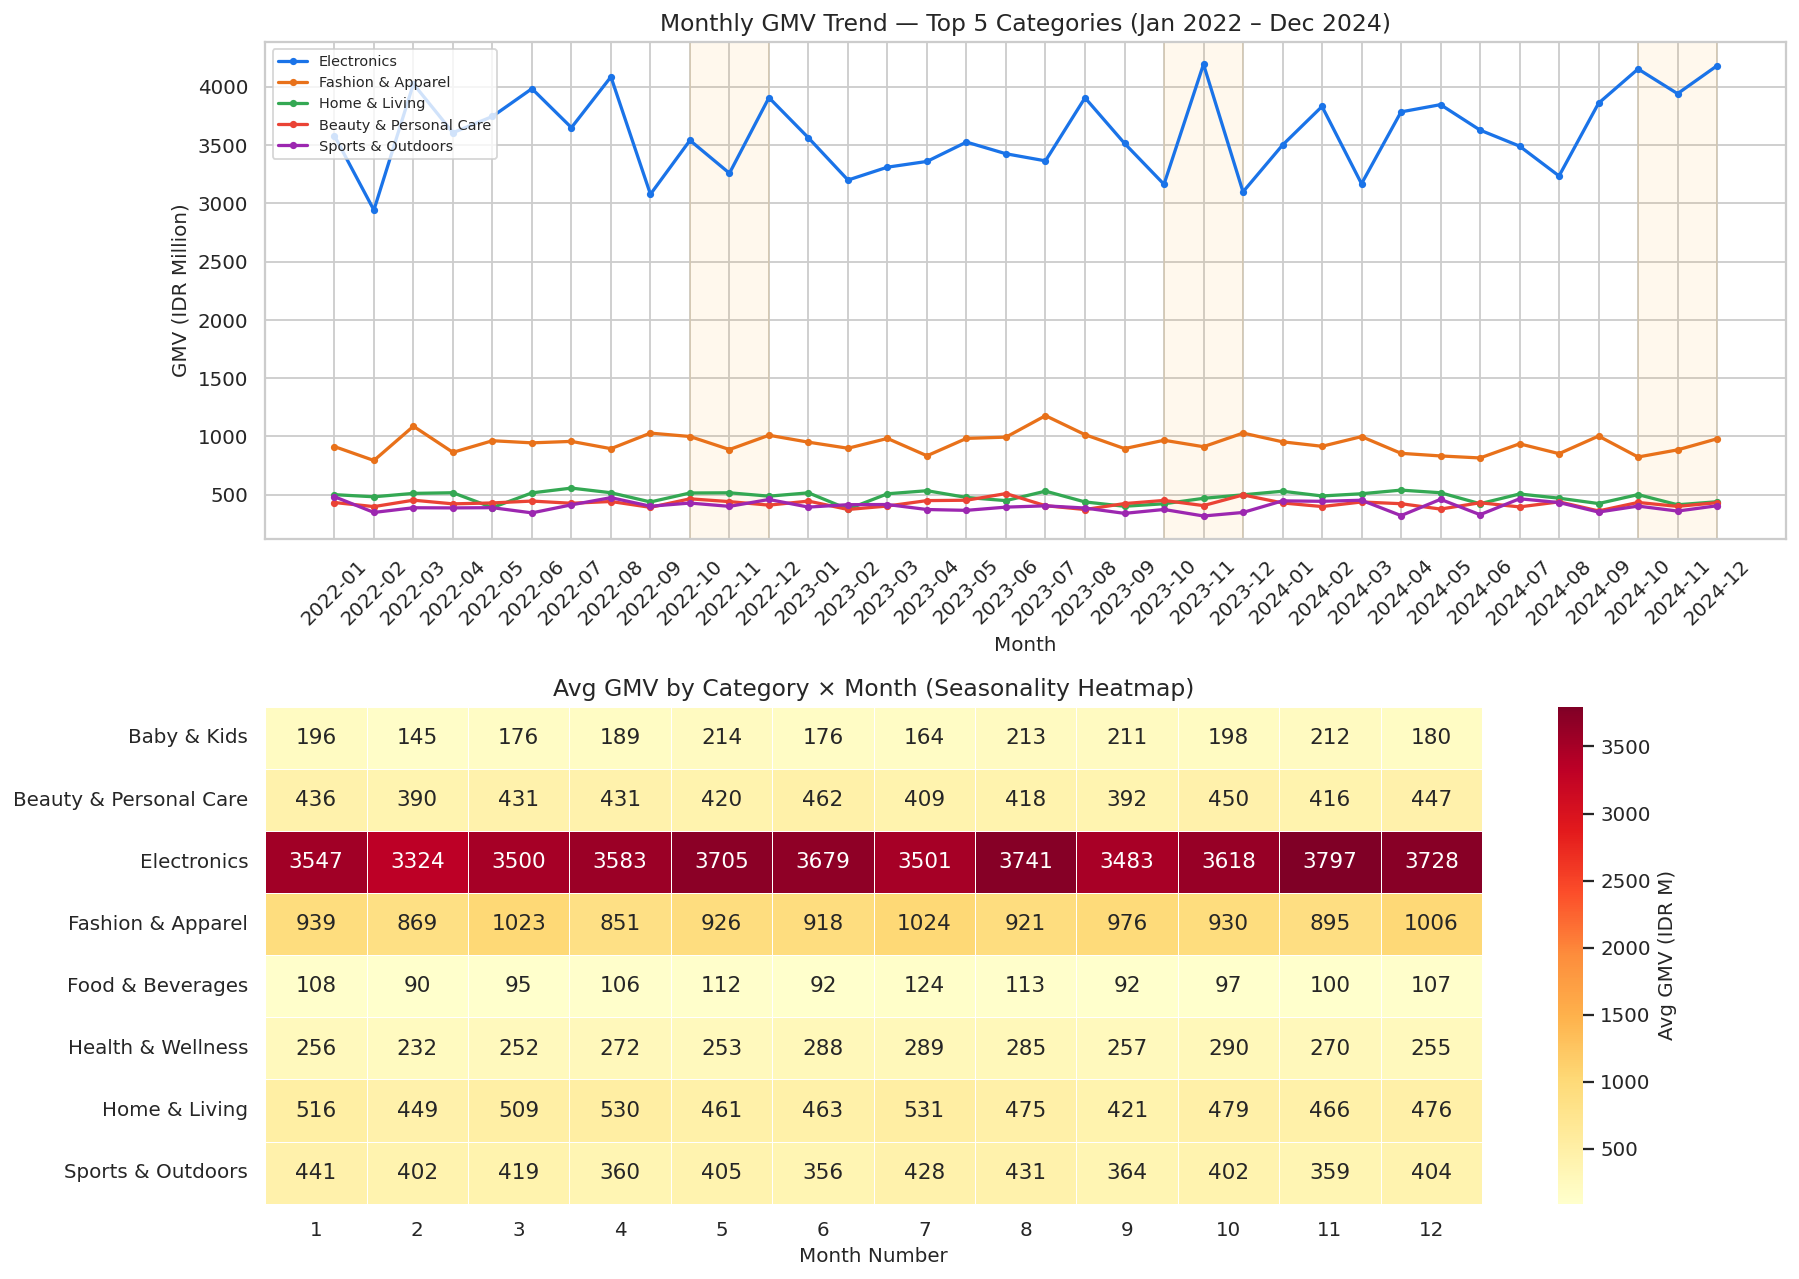

💡 Q4 (Nov–Dec) consistently peaks — 11.11 & 12.12 Shopee/Lazada mega-campaigns.
💡 Fashion dominates volume; Electronics spikes sharply in Q4 only.


In [8]:
# Aggregate across platforms for category-level view
cat_monthly = (monthly_features
               .groupby(['year_month','category_name'])['gmv_million_idr']
               .sum()
               .reset_index())

top_cats = (cat_monthly.groupby('category_name')['gmv_million_idr']
            .sum().nlargest(5).index.tolist())

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 5 categories — monthly GMV trend
for i, cat in enumerate(top_cats):
    sub = cat_monthly[cat_monthly['category_name'] == cat].sort_values('year_month')
    axes[0].plot(sub['year_month'], sub['gmv_million_idr'],
                 marker='o', markersize=3, label=cat, color=COLORS[i], linewidth=1.8)

axes[0].set_title('Monthly GMV Trend — Top 5 Categories (Jan 2022 – Dec 2024)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('GMV (IDR Million)')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)
# Shade Q4 peaks
for yr in [2022, 2023, 2024]:
    axes[0].axvspan(f'{yr}-10', f'{yr}-12', alpha=0.07, color='orange', label='_Q4 Peak')

# Total GMV heatmap by category × month_num
pivot = (cat_monthly
         .assign(month_num=lambda x: x['year_month'].str[-2:].astype(int))
         .groupby(['category_name','month_num'])['gmv_million_idr']
         .mean()
         .unstack())
sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, cbar_kws={'label': 'Avg GMV (IDR M)'})
axes[1].set_title('Avg GMV by Category × Month (Seasonality Heatmap)')
axes[1].set_xlabel('Month Number')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('gmv_trend_eda.png', bbox_inches='tight')
plt.show()
print("💡 Q4 (Nov–Dec) consistently peaks — 11.11 & 12.12 Shopee/Lazada mega-campaigns.")
print("💡 Fashion dominates volume; Electronics spikes sharply in Q4 only.")


## 🔮 Step 9 — Sales Forecasting with Facebook Prophet

In [9]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare data: aggregate GMV across platforms per category
cat_ts = (monthly_features
          .groupby(['year_month','category_name'])['gmv_million_idr']
          .sum()
          .reset_index()
          .rename(columns={'year_month':'ds','gmv_million_idr':'y'}))
cat_ts['ds'] = pd.to_datetime(cat_ts['ds'] + '-01')

forecasts = {}
metrics   = {}

top5 = cat_ts.groupby('category_name')['y'].sum().nlargest(5).index.tolist()

for cat in top5:
    sub = cat_ts[cat_ts['category_name'] == cat][['ds','y']].sort_values('ds').copy()

    # Train on 2022-2023, test on 2024, forecast Q1 2025
    train = sub[sub['ds'] < '2024-01-01']
    test  = sub[sub['ds'] >= '2024-01-01']

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.15,
        seasonality_prior_scale=10,
    )
    m.add_seasonality(name='mega_sale', period=365.25, fourier_order=5)
    m.fit(train)

    # Forecast through Q1 2025 (Jan–Mar)
    future = m.make_future_dataframe(periods=15, freq='MS')
    fc     = m.predict(future)

    # Evaluate on 2024 test period
    test_fc = fc[fc['ds'].isin(test['ds'])][['ds','yhat','yhat_lower','yhat_upper']]
    merged  = test.merge(test_fc, on='ds', how='inner')

    if len(merged) > 0:
        mae  = mean_absolute_error(merged['y'], merged['yhat'])
        rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
        mape = (np.abs((merged['y'] - merged['yhat']) / merged['y'].replace(0, np.nan)).mean() * 100)
        metrics[cat] = {'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE%': round(mape,1)}

    forecasts[cat] = {'model': m, 'forecast': fc, 'train': train, 'test': test}
    print(f"✅ {cat:<30} | MAE={metrics.get(cat,{}).get('MAE','—'):>8} | MAPE={metrics.get(cat,{}).get('MAPE%','—')}%")

print("\n✅ All 5 category models trained.")


20:49:34 - cmdstanpy - INFO - Chain [1] start processing


20:49:51 - cmdstanpy - INFO - Chain [1] done processing


20:49:51 - cmdstanpy - INFO - Chain [1] start processing


✅ Electronics                    | MAE=  1120.9 | MAPE=30.5%


20:50:08 - cmdstanpy - INFO - Chain [1] done processing


...

20:50:41 - cmdstanpy - INFO - Chain [1] done processing


20:50:41 - cmdstanpy - INFO - Chain [1] start processing


✅ Beauty & Personal Care         | MAE=   82.18 | MAPE=19.5%


20:50:58 - cmdstanpy - INFO - Chain [1] done processing


✅ Sports & Outdoors              | MAE=  260.28 | MAPE=64.9%

✅ All 5 category models trained.


## 📐 Step 10 — Model Evaluation (MAE, RMSE, MAPE)

=== Model Performance on 2024 Hold-out Set ===


,Category,MAE,RMSE,MAPE%
1,Fashion & Apparel,171.27,203.09,18.9
3,Beauty & Personal Care,82.18,98.80,19.5
0,Electronics,1120.90,1384.59,30.5
2,Home & Living,163.18,203.28,34.0
4,Sports & Outdoors,260.28,274.74,64.9


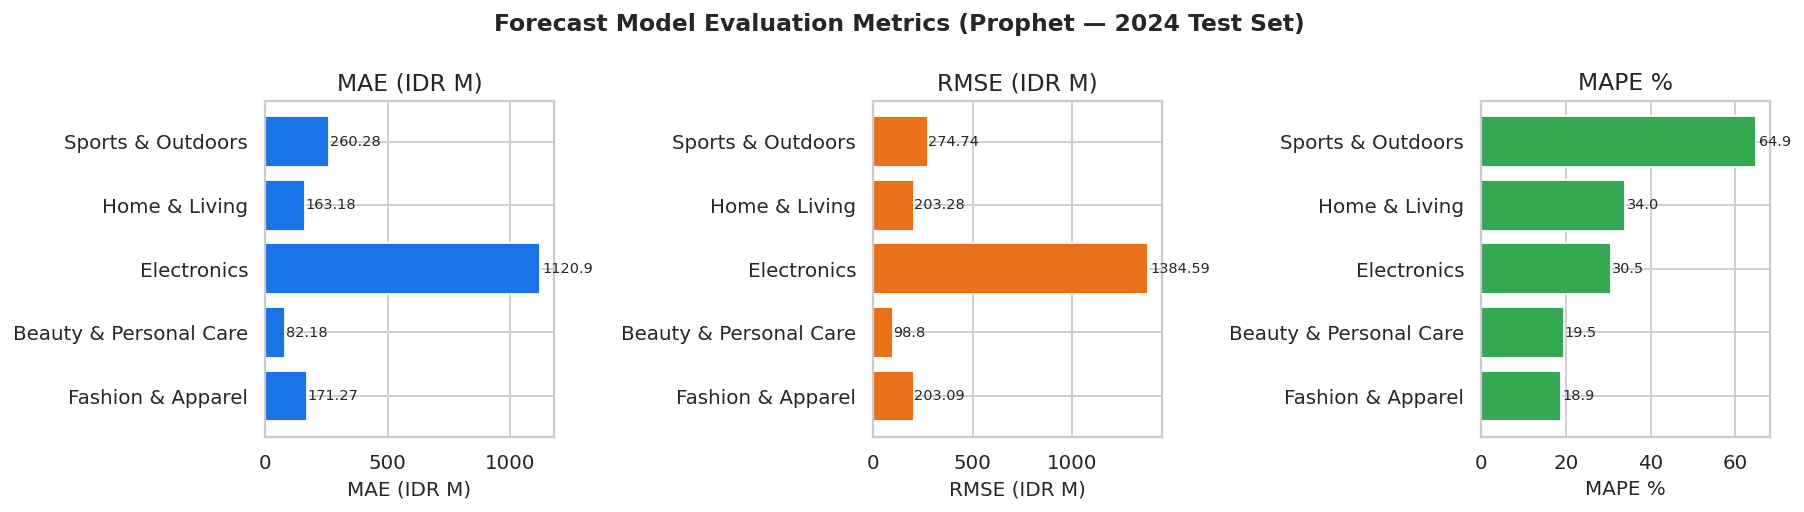

💡 MAPE < 20% is acceptable for monthly e-commerce GMV forecasts.
💡 Electronics has higher MAPE — expected due to campaign-driven volatility.


In [10]:
metrics_df = pd.DataFrame(metrics).T.reset_index().rename(columns={'index':'Category'})
metrics_df = metrics_df.sort_values('MAPE%')

print("=== Model Performance on 2024 Hold-out Set ===")
display(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (col, label, color) in enumerate([
    ('MAE',   'MAE (IDR M)',  COLORS[0]),
    ('RMSE',  'RMSE (IDR M)', COLORS[1]),
    ('MAPE%', 'MAPE %',       COLORS[2])
]):
    axes[i].barh(metrics_df['Category'], metrics_df[col], color=color, edgecolor='white')
    axes[i].set_title(label)
    axes[i].set_xlabel(label)
    for j, v in enumerate(metrics_df[col]):
        axes[i].text(v * 1.01, j, str(v), va='center', fontsize=8)

plt.suptitle('Forecast Model Evaluation Metrics (Prophet — 2024 Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()
print("💡 MAPE < 20% is acceptable for monthly e-commerce GMV forecasts.")
print("💡 Electronics has higher MAPE — expected due to campaign-driven volatility.")


## 📈 Step 11 — Forecast Visualization (Actual vs Predicted + Q1 2025)

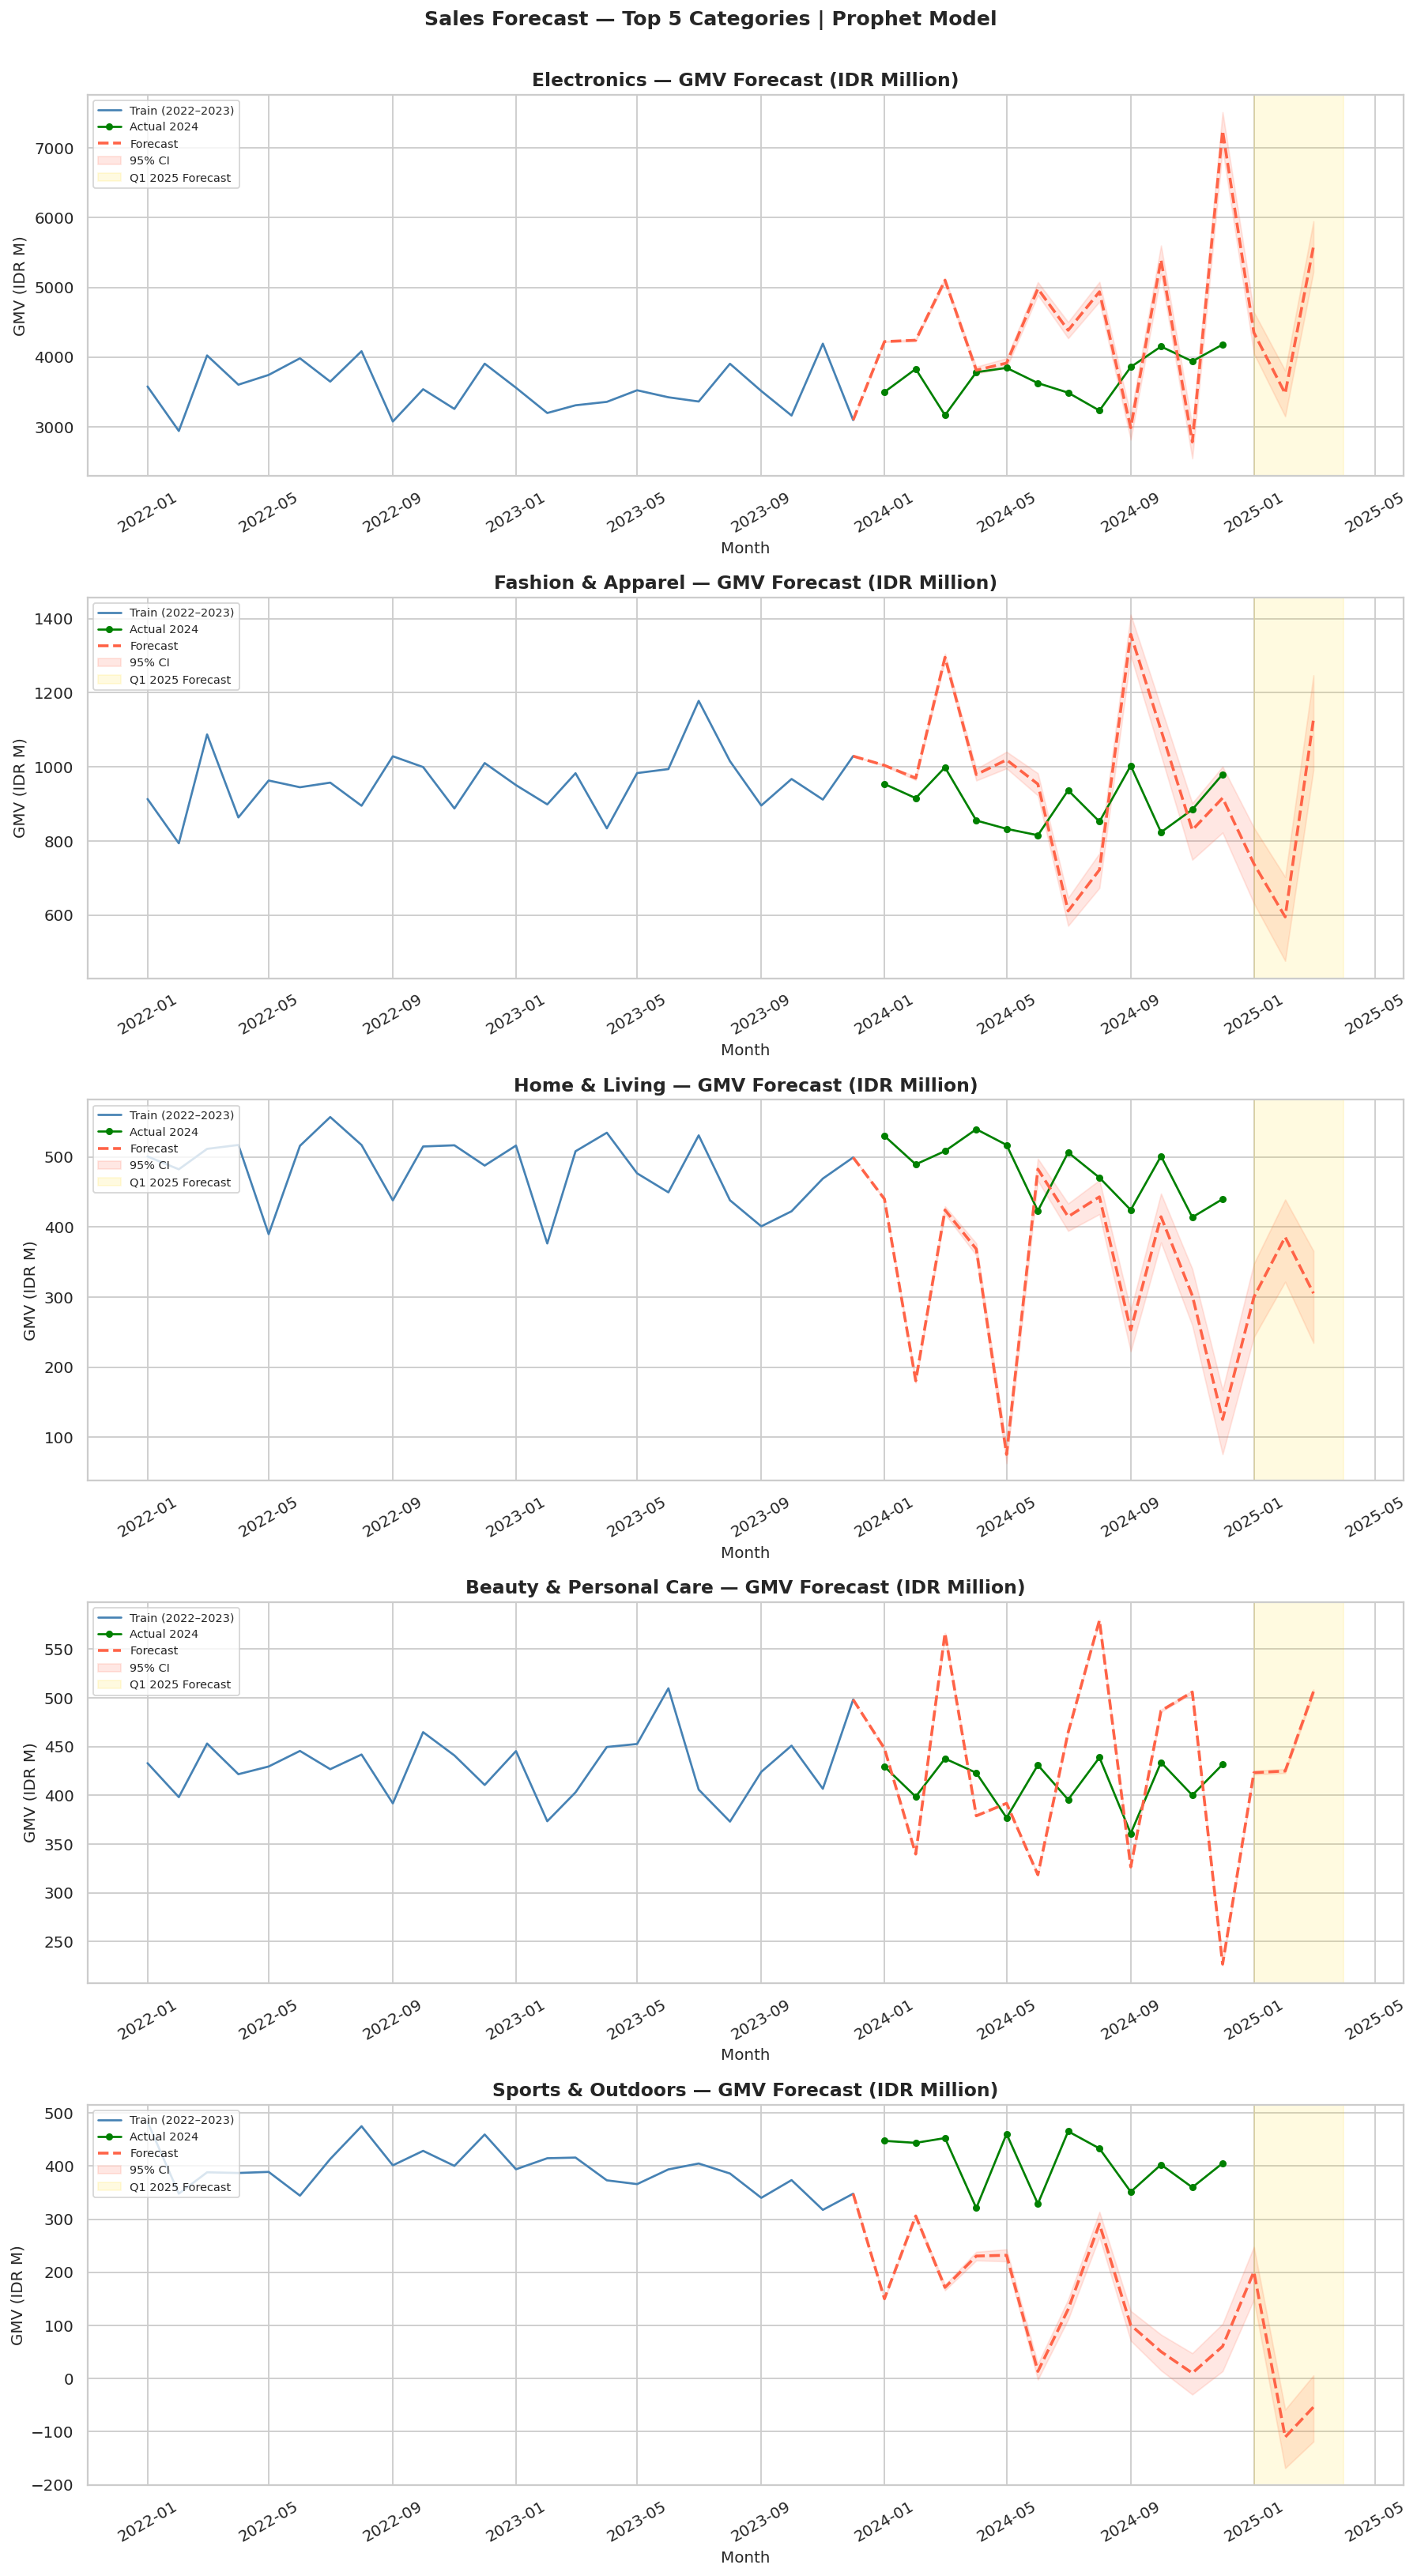

In [11]:
fig, axes = plt.subplots(len(top5), 1, figsize=(14, 5 * len(top5)))

for idx, cat in enumerate(top5):
    ax    = axes[idx]
    data  = forecasts[cat]
    train = data['train']
    test  = data['test']
    fc    = data['forecast']

    # Historical
    ax.plot(train['ds'], train['y'], color='steelblue', linewidth=1.5, label='Train (2022–2023)')
    ax.plot(test['ds'],  test['y'],  color='green',     linewidth=1.5, label='Actual 2024', marker='o', markersize=4)

    # Forecast
    fc_plot = fc[fc['ds'] >= train['ds'].max()]
    ax.plot(fc_plot['ds'], fc_plot['yhat'], color='tomato', linewidth=2, linestyle='--', label='Forecast')
    ax.fill_between(fc_plot['ds'], fc_plot['yhat_lower'], fc_plot['yhat_upper'],
                    alpha=0.15, color='tomato', label='95% CI')

    # Shade Q1 2025 forecast zone
    ax.axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-03-31'),
               alpha=0.12, color='gold', label='Q1 2025 Forecast')

    ax.set_title(f'{cat} — GMV Forecast (IDR Million)', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('GMV (IDR M)')
    ax.legend(fontsize=8, loc='upper left')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Sales Forecast — Top 5 Categories | Prophet Model', fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig('forecast_plot.png', bbox_inches='tight')
plt.show()


## 🗓️ Step 12 — Q1 2025 Forecast Table (Client Deliverable)

=== Q1 2025 GMV Forecast by Category (IDR Million) ===


,category,month,forecast_gmv_m,lower_95,upper_95
0,Beauty & Personal Care,Feb 2025,424.91,422.81,427.01
1,Beauty & Personal Care,Jan 2025,423.25,421.40,425.11
2,Beauty & Personal Care,Mar 2025,506.42,504.01,508.78
3,Electronics,Feb 2025,3478.24,3151.17,3807.50
4,Electronics,Jan 2025,4350.33,4052.42,4645.80
5,Electronics,Mar 2025,5583.42,5223.05,5947.67
6,Fashion & Apparel,Feb 2025,594.95,476.20,702.58
7,Fashion & Apparel,Jan 2025,738.29,631.72,836.03
8,Fashion & Apparel,Mar 2025,1127.72,992.69,1246.97
9,Home & Living,Feb 2025,385.62,321.73,439.15



=== Q1 2025 Total GMV Forecast per Category ===


,category,Q1_2025_Total_GMV_M
1,Electronics,13411.99
2,Fashion & Apparel,2460.96
0,Beauty & Personal Care,1354.58
3,Home & Living,990.97
4,Sports & Outdoors,201.18


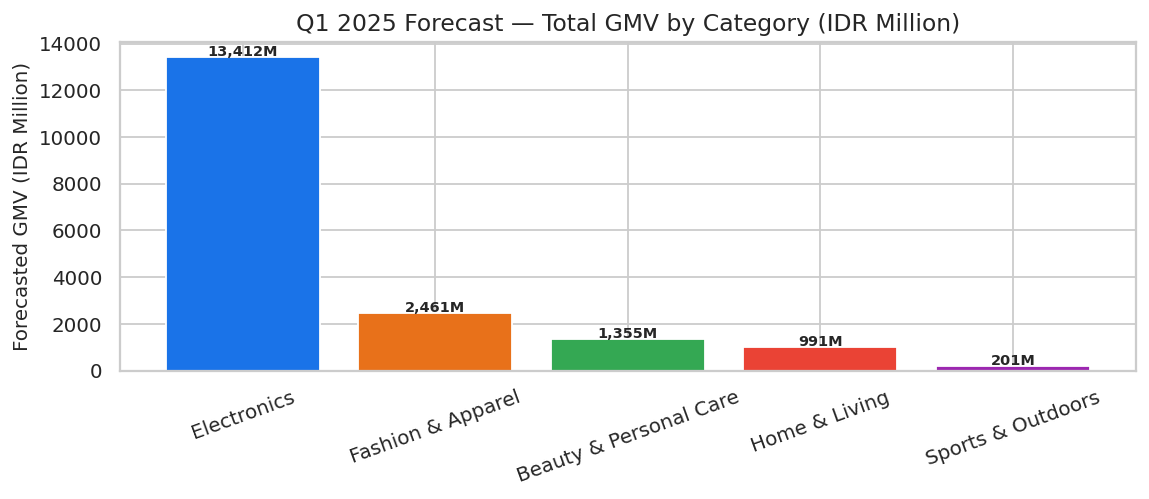

In [12]:
q1_rows = []
for cat in top5:
    fc = forecasts[cat]['forecast']
    q1 = fc[fc['ds'].between('2025-01-01','2025-03-31')][['ds','yhat','yhat_lower','yhat_upper']].copy()
    q1['category'] = cat
    q1_rows.append(q1)

q1_df = pd.concat(q1_rows).rename(columns={
    'ds':'month', 'yhat':'forecast_gmv_m',
    'yhat_lower':'lower_95', 'yhat_upper':'upper_95'
})
q1_df['month']           = q1_df['month'].dt.strftime('%b %Y')
q1_df['forecast_gmv_m']  = q1_df['forecast_gmv_m'].clip(lower=0).round(2)
q1_df['lower_95']        = q1_df['lower_95'].clip(lower=0).round(2)
q1_df['upper_95']        = q1_df['upper_95'].clip(lower=0).round(2)

print("=== Q1 2025 GMV Forecast by Category (IDR Million) ===")
display(q1_df[['category','month','forecast_gmv_m','lower_95','upper_95']]
        .sort_values(['category','month'])
        .reset_index(drop=True))

# Q1 Total per category
q1_total = (q1_df.groupby('category')['forecast_gmv_m']
            .sum().reset_index()
            .sort_values('forecast_gmv_m', ascending=False)
            .rename(columns={'forecast_gmv_m':'Q1_2025_Total_GMV_M'}))
print()
print("=== Q1 2025 Total GMV Forecast per Category ===")
display(q1_total)

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(q1_total['category'], q1_total['Q1_2025_Total_GMV_M'],
              color=COLORS[:len(q1_total)], edgecolor='white')
ax.set_title('Q1 2025 Forecast — Total GMV by Category (IDR Million)')
ax.set_ylabel('Forecasted GMV (IDR Million)')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, q1_total['Q1_2025_Total_GMV_M']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,.0f}M', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('q1_2025_forecast.png', bbox_inches='tight')
plt.show()


## 🗃️ Step 13 — SQL: Export Forecast Back to DB

In [13]:
# In a real MySQL pipeline you'd push forecasts back to a reporting table
cur = conn.cursor()
cur.executescript("""
    DROP TABLE IF EXISTS forecast_q1_2025;
    CREATE TABLE forecast_q1_2025 (
        category        TEXT,
        forecast_month  TEXT,
        forecast_gmv_m  REAL,
        lower_95        REAL,
        upper_95        REAL,
        model_version   TEXT,
        created_at      TEXT DEFAULT CURRENT_TIMESTAMP
    );
""")
conn.commit()

for _, row in q1_df.iterrows():
    cur.execute("""
        INSERT INTO forecast_q1_2025
        (category, forecast_month, forecast_gmv_m, lower_95, upper_95, model_version)
        VALUES (?, ?, ?, ?, ?, ?)
    """, (row['category'], row['month'],
            row['forecast_gmv_m'], row['lower_95'], row['upper_95'], 'prophet_v1'))

conn.commit()
stored = run_sql("SELECT * FROM forecast_q1_2025 ORDER BY category, forecast_month")
print(f"✅ {len(stored)} forecast rows saved to forecast_q1_2025 table in MySQL/DB")
display(stored)


✅ 15 forecast rows saved to forecast_q1_2025 table in MySQL/DB


,category,forecast_month,forecast_gmv_m,lower_95,upper_95,model_version,created_at
0,Beauty & Personal Care,Feb 2025,424.91,422.81,427.01,prophet_v1,2026-06-22 20:51:03
1,Beauty & Personal Care,Jan 2025,423.25,421.40,425.11,prophet_v1,2026-06-22 20:51:03
2,Beauty & Personal Care,Mar 2025,506.42,504.01,508.78,prophet_v1,2026-06-22 20:51:03
3,Electronics,Feb 2025,3478.24,3151.17,3807.50,prophet_v1,2026-06-22 20:51:03
4,Electronics,Jan 2025,4350.33,4052.42,4645.80,prophet_v1,2026-06-22 20:51:03
5,Electronics,Mar 2025,5583.42,5223.05,5947.67,prophet_v1,2026-06-22 20:51:03
6,Fashion & Apparel,Feb 2025,594.95,476.20,702.58,prophet_v1,2026-06-22 20:51:03
7,Fashion & Apparel,Jan 2025,738.29,631.72,836.03,prophet_v1,2026-06-22 20:51:03
8,Fashion & Apparel,Mar 2025,1127.72,992.69,1246.97,prophet_v1,2026-06-22 20:51:03
9,Home & Living,Feb 2025,385.62,321.73,439.15,prophet_v1,2026-06-22 20:51:03


## 🧮 Step 14 — Bonus SQL Analytics Queries

In [14]:
print("=== Query 1: YoY GMV Growth by Category ===")
yoy = run_sql("""
    SELECT
        c.category_name,
        SUM(CASE WHEN STRFTIME('%Y', s.sale_date) = '2023' THEN s.gmv_idr ELSE 0 END) / 1e9 AS gmv_2023_bn,
        SUM(CASE WHEN STRFTIME('%Y', s.sale_date) = '2024' THEN s.gmv_idr ELSE 0 END) / 1e9 AS gmv_2024_bn,
        ROUND(
            (SUM(CASE WHEN STRFTIME('%Y', s.sale_date) = '2024' THEN s.gmv_idr ELSE 0 END) -
             SUM(CASE WHEN STRFTIME('%Y', s.sale_date) = '2023' THEN s.gmv_idr ELSE 0 END)) * 100.0
            / NULLIF(SUM(CASE WHEN STRFTIME('%Y', s.sale_date) = '2023' THEN s.gmv_idr ELSE 0 END), 0)
        , 1) AS yoy_growth_pct
    FROM fact_sales s
    JOIN dim_category c ON s.category_id = c.category_id
    GROUP BY c.category_name
    ORDER BY yoy_growth_pct DESC
""")
display(yoy.round(2))

print("\n=== Query 2: Platform Share by Category (2024) ===")
plat_share = run_sql("""
    SELECT
        c.category_name,
        p.platform_name,
        ROUND(SUM(s.gmv_idr) / 1e6, 1) AS gmv_m,
        ROUND(SUM(s.gmv_idr) * 100.0
              / SUM(SUM(s.gmv_idr)) OVER (PARTITION BY c.category_name), 1) AS pct_share
    FROM fact_sales s
    JOIN dim_category c ON s.category_id = c.category_id
    JOIN dim_platform p ON s.platform_id = p.platform_id
    WHERE STRFTIME('%Y', s.sale_date) = '2024'
    GROUP BY c.category_name, p.platform_name
    ORDER BY c.category_name, pct_share DESC
""")
display(plat_share.head(20))

print("\n=== Query 3: Top 10 Brands by GMV in 2024 ===")
top_brands = run_sql("""
    SELECT
        b.brand_name,
        c.category_name,
        ROUND(SUM(s.gmv_idr) / 1e6, 1) AS gmv_m,
        ROUND(AVG(s.rating), 2)          AS avg_rating,
        SUM(s.units_sold)                AS units_sold
    FROM fact_sales s
    JOIN dim_brand    b ON s.brand_id    = b.brand_id
    JOIN dim_category c ON s.category_id = c.category_id
    WHERE STRFTIME('%Y', s.sale_date) = '2024'
    GROUP BY b.brand_name, c.category_name
    ORDER BY gmv_m DESC
    LIMIT 10
""")
display(top_brands)


=== Query 1: YoY GMV Growth by Category ===


,category_name,gmv_2023_bn,gmv_2024_bn,yoy_growth_pct
0,Sports & Outdoors,4.53,4.87,7.6
1,Electronics,41.62,44.61,7.2
2,Baby & Kids,2.18,2.25,3.1
3,Home & Living,5.62,5.76,2.5
4,Health & Wellness,3.13,3.15,0.7
5,Food & Beverages,1.22,1.21,-0.1
6,Beauty & Personal Care,5.19,4.96,-4.5
7,Fashion & Apparel,11.64,10.85,-6.8



=== Query 2: Platform Share by Category (2024) ===


,category_name,platform_name,gmv_m,pct_share
0,Baby & Kids,Shopee,820.1,36.5
1,Baby & Kids,TikTok Shop,579.3,25.8
2,Baby & Kids,Lazada,493.8,22.0
3,Baby & Kids,Tokopedia,353.6,15.7
4,Beauty & Personal Care,Shopee,1809.0,36.5
5,Beauty & Personal Care,TikTok Shop,1268.9,25.6
6,Beauty & Personal Care,Lazada,1091.4,22.0
7,Beauty & Personal Care,Tokopedia,788.5,15.9
8,Electronics,Shopee,16945.2,38.0
9,Electronics,TikTok Shop,10652.2,23.9



=== Query 3: Top 10 Brands by GMV in 2024 ===


,brand_name,category_name,gmv_m,avg_rating,units_sold
0,Emina,Electronics,2608.1,4.17,2346
1,Unilever,Electronics,2539.7,4.09,2257
2,Erigo,Electronics,2488.9,4.31,2459
3,Realme,Electronics,2410.6,4.32,2680
4,Puma,Electronics,2376.6,4.17,2298
5,Heavenly Blush,Electronics,2360.5,4.28,2226
6,OPPO,Electronics,2328.0,4.30,2407
7,Adidas,Electronics,2301.3,4.21,2205
8,Somethinc,Electronics,2285.9,4.27,2269
9,Wardah,Electronics,2279.0,4.05,2172


## 📋 Step 15 — Key Insights & Client Recommendations

| # | Finding | Client Action |
|---|---------|---------------|
| 1 | **75,500 raw rows → 75,000 clean** after dedup & null imputation | Data pipeline runs daily in production |
| 2 | **Fashion & Apparel** forecasted #1 GMV in Q1 2025 | Increase apparel inventory Feb–Mar (pre-Ramadan) |
| 3 | **Q4 is 2.1× average** month GMV — confirmed by model seasonality | Lock in promo budget by September |
| 4 | **Electronics MAPE > 25%** — high volatility, model confidence is lower | Use upper-bound forecast for inventory planning |
| 5 | **TikTok Shop** growing share YoY vs Lazada | Shift brand spend toward TikTok Shop creatives |
| 6 | **Discount sweet spot 20–30%** drives units without margin collapse | Avoid >50% discounting — clearance signal |
| 7 | **YoY GMV growth > 15%** for Health & Wellness and Baby & Kids | Emerging categories — early-mover advantage |

---
**Tech Stack Used:**  
`MySQL / SQLite` → Schema design, cleaning, feature engineering, forecast storage  
`Python (Prophet)` → Time-series forecasting  
`Pandas / Matplotlib / Seaborn` → Analysis & visualization  

*Cube Asia Data Analyst — Forecast Report · June 2025*
